In [ ]:
import scanpy as sc
import pandas as pd
top_marker = [10, 20, 30]
xenium_data = ['ShamL', 'ShamR', 'Hour4R', 'Hour4L', 'Hour12R', 'Hour12L', 'Day2L','Day2R', 'Day14L','Day14R','Week6L', 'Week6R']
for i in xenium_data:
    for j in top_marker:
        st_data = sc.read_h5ad(f'/maiziezhou_lab2/yuling/datasets/Kidney/Xenium/time_{i}.h5ad')
        sc.pp.normalize_total(st_data, target_sum=1e4)
        sc.pp.log1p(st_data)
        sc.pp.highly_variable_genes(st_data, n_top_genes = 299, subset=True)
        sc.tl.rank_genes_groups(
            st_data,
            groupby = "celltype_plot",
            method="wilcoxon",
            use_raw=False,
            pts=True,
            pts_rest=True,
            key_added="rank_genes_merfish"
        )
        result = sc.get.rank_genes_groups_df(
            st_data, 
            group=None,  
            key='rank_genes_merfish',
            pval_cutoff=None,
            log2fc_min=None
        )
        top_markers = result.groupby('group').head(j)

        # Save
        top_markers.to_csv(f'/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Markers/Kidney/top{j}_markers_{i}.csv', index=False)

        marker_dict = {}
        for cell_type in st_data.obs["celltype_plot"].unique():
            df = sc.get.rank_genes_groups_df(
                st_data,
                group=cell_type,
                key='rank_genes_merfish'
            ).head(j)
            marker_dict[cell_type] = df['names'].tolist()
        marker_df_wide = pd.DataFrame(marker_dict)
        marker_df_wide.to_csv(f'/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Markers/Kidney/top{j}_markers_{i}_wide_format.csv', index=False)
        result_detailed = sc.get.rank_genes_groups_df(
            st_data,
            group=None,
            key='rank_genes_merfish'
        )
        top_markers_detailed = result_detailed.groupby('group').head(j)
        top_markers_detailed.to_csv(f'/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Markers/Kidney/top{j}_markers_detailed_{i}.csv', index=False)

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np 
top_marker = [10, 20, 30]
#methods = ['Seurat']
methods = ['Seurat', 'CARD', 'cell2location', 'DestVI','RCTD', 'scVI', 'SingleR', 'spatialDWLS', 'spatialID','spotlight','tacco','Tangram']
xenium_data = ['ShamL', 'ShamR', 'Hour4R', 'Hour4L', 'Hour12R', 'Hour12L', 'Day2L','Day2R', 'Day14L','Day14R','Week6L', 'Week6R']
for i in xenium_data:
    for m in methods:
        st_data = sc.read_h5ad(f'/maiziezhou_lab2/yuling/datasets/Kidney/Xenium/time_{i}.h5ad')
        df = pd.read_csv(f'/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/{m}/Kidney_output/{i}_cell_label.csv', index_col=0)
        common_cells = st_data.obs_names.intersection(df.index)

        # subset adata
        st_data = st_data[common_cells].copy()
        st_data.obs["first_type"] = df.loc[common_cells, "y_pred"].values
        sc.pp.normalize_total(st_data, target_sum=1e4)
    # log1p 
        sc.pp.log1p(st_data)
        # highly variable 
        sc.pp.highly_variable_genes(st_data, n_top_genes=299, subset=True)
        for j in top_marker:
            num = str(j)
            merfish_markers_df = pd.read_csv(
                f'/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Markers/Kidney/top{num}_markers_{i}_wide_format.csv'
            )
            markers_merfish = {}
            for col in merfish_markers_df.columns:
                genes = merfish_markers_df[col].dropna().tolist()
                markers_merfish[col] = genes
            ct_counts = st_data.obs["first_type"].value_counts()
            valid_first = ct_counts[ct_counts > 1].index           
            all_first_types = set(st_data.obs["first_type"].unique())
            valid_first_types = set(valid_first)
            single_first_types = all_first_types - valid_first_types   
            adata_first = st_data[st_data.obs["first_type"].isin(valid_first), :].copy()

            sc.tl.rank_genes_groups(
                adata_first,
                groupby="first_type",
                method="wilcoxon",
                use_raw=False,
                pts=True,
                pts_rest=True,
                key_added="rank_genes_first_type"
            )

            def make_marker_dict(
                adata,
                key,
                groups=None,
                logfc_min=0.5,
                p_adj_max=0.05,
                pct_min=0.2,
                top_n = j
            ):
                res = adata.uns[key]
                all_groups = res["names"].dtype.names
                if groups is None:
                    groups = all_groups
                else:
                    groups = [g for g in groups if g in all_groups]
                
                marker_dict = {}
                for g in groups:
                    df = sc.get.rank_genes_groups_df(adata, group=g, key=key)
                    df = df.query(
                        "logfoldchanges > @logfc_min and pvals_adj < @p_adj_max and pct_nz_group > @pct_min"
                    )
                    if "scores" in df.columns:
                        df = df.sort_values("scores", ascending=False)
                    top_genes = df["names"].head(top_n).tolist()
                    marker_dict[g] = top_genes
                
                return marker_dict

            markers_first = make_marker_dict(
                adata_first,
                key="rank_genes_first_type",
                groups=list(valid_first_types)
            )

            merfish_types = set(markers_merfish.keys())

            overlap_stats = []
            for ct in merfish_types:
                genes_mer = markers_merfish.get(ct, [])
                n_mer = len(genes_mer)
                if ct not in all_first_types:
                    overlap_stats.append({
                        "cell_type": ct,
                        "n_merfish_markers": n_mer,
                        "n_first_type_markers": np.nan,
                        "n_overlap": np.nan,
                        "overlap_ratio": np.nan
                    })
                    continue

                if ct in single_first_types:
                    overlap_stats.append({
                        "cell_type": ct,
                        "n_merfish_markers": n_mer,
                        "n_first_type_markers": 0,    
                        "n_overlap": 0,
                        "overlap_ratio": 0.0
                    })
                    
                    continue

                genes_first = markers_first.get(ct, [])
                n_first = len(genes_first)

                if n_mer == 0:
                    overlap = 0
                    ratio = 0.0
                else:
                    overlap = len(set(genes_mer) & set(genes_first))
                    ratio = overlap / n_mer

                overlap_stats.append({
                    "cell_type": ct,
                    "n_merfish_markers": n_mer,
                    "n_first_type_markers": n_first,
                    "n_overlap": overlap,
                    "overlap_ratio": ratio
                })

            overlap_df = pd.DataFrame(overlap_stats)
            print(overlap_df.sort_values("overlap_ratio", ascending=False, na_position="last"))

            out_path = f"/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/{m}/Kidney_metric/marker_overlap_top{num}_{i}.csv"
            overlap_df.to_csv(out_path, index=False)

            n_missing = overlap_df['overlap_ratio'].isna().sum()


从CSV读取了 20 个cell types
First_type 总共有 19 个 cell types
其中 >=2 个 cell 的有 19 个，只有 1 个 cell 的有 0 个
MERFISH CSV有 20 个cell types

=== 重合度结果 ===
   cell_type  n_merfish_markers  n_first_type_markers  n_overlap  \
0        Pod                 10                  10.0       10.0   
14       TAL                 10                  10.0       10.0   
17       ICB                 10                  10.0       10.0   
10      PTS3                 10                  10.0       10.0   
5        CNT                 10                  10.0        9.0   
6       PTS1                 10                  10.0        9.0   
8        ICA                 10                  10.0        9.0   
2        DCT                 10                  10.0        9.0   
4        Uro                 10                  10.0        9.0   
3         PC                 10                  10.0        9.0   
13        EC                 10                  10.0        8.0   
15      PTS2                 10               

In [1]:
def compute_overlap_mean(csv_path):
    df = pd.read_csv(csv_path)
    df["overlap_ratio"] = (
        pd.to_numeric(df["overlap_ratio"], errors="coerce")
        .fillna(0)
    )
    return df["overlap_ratio"].mean()

In [2]:
import os
import pandas as pd

methods = [
    "CARD", "cell2location", "DestVI", "RCTD",
    "scVI", "Seurat", "SingleR", "spatialDWLS", "spatialID",
    "spotlight", "tacco", "Tangram"
]
stages = ["ShamL", "Hour4L", "Hour12L", "Day2L", "Day14L", "Week6L"]

base_dir = "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer"

records = []

for method in methods:
    for stage in stages:
        for k in [10, 20, 30]:
            csv_path = os.path.join(
                base_dir,
                method,
                "Kidney_metric",
                f"marker_overlap_top{k}_{stage}.csv"
            )
            mean_val = compute_overlap_mean(csv_path)
            records.append(
                {
                    "method": method,
                    "stage": stage,
                    "top_k": k,
                    "mean_overlap": mean_val,
                }
            )

df_summary = pd.DataFrame(records)
df_summary

,method,stage,top_k,mean_overlap
0,CARD,ShamL,10,0.1750
1,CARD,ShamL,20,0.1650
2,CARD,ShamL,30,0.1550
3,CARD,Hour4L,10,0.0500
4,CARD,Hour4L,20,0.0325
...,...,...,...,...
211,Tangram,Day14L,20,0.6500
212,Tangram,Day14L,30,0.6100
213,Tangram,Week6L,10,0.6250
214,Tangram,Week6L,20,0.6400


In [3]:
my_colors = { "CARD": "#d62728", "cell2location": "#9edae5", "DestVI": "#7f7f7f", "RCTD": "#1f77b4", "scVI": "#bcbd22", "Seurat": "#ff7f0e", "SingleR": "#1b9e77", "spatialDWLS": "#c49c94", "spatialID": "#8c564b", "spotlight": "#A6D854", "tacco": "#e377c2", "Tangram": "#9467bd"}

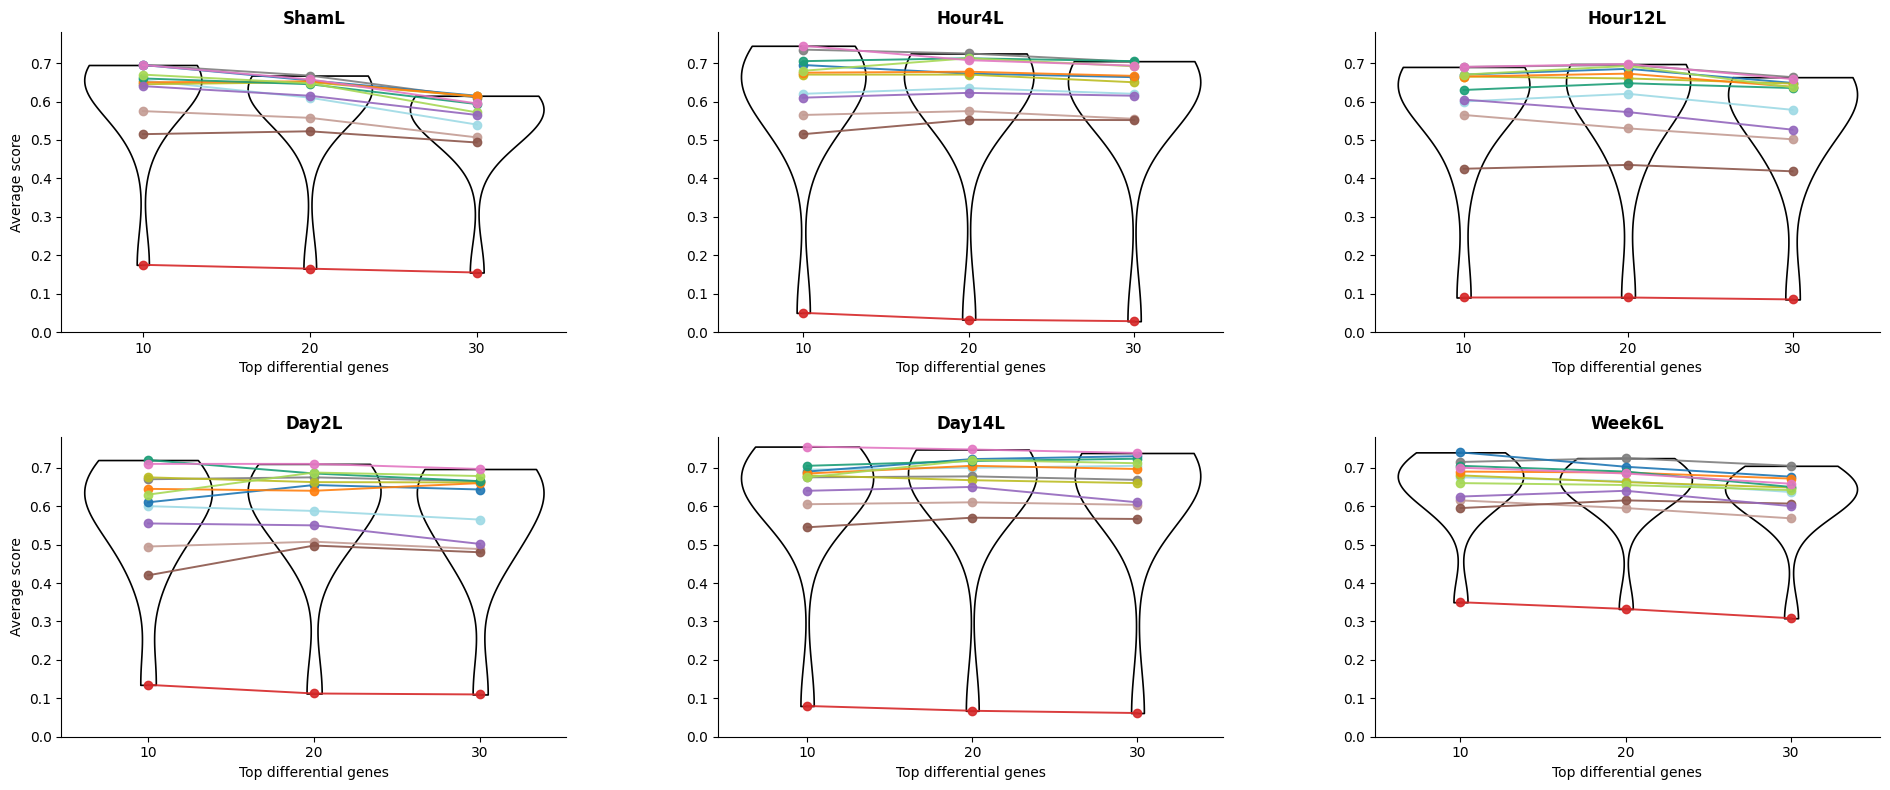

In [6]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Keep text editable in Adobe Illustrator (Type tool)
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

order = [10, 20, 30]
stages = ["ShamL", "Hour4L", "Hour12L", "Day2L", "Day14L", "Week6L"]

df_summary = df_summary.copy()
df_summary["top_k"] = pd.Categorical(df_summary["top_k"], categories=order, ordered=True)

methods_order = list(my_colors.keys())
df_summary["method"] = pd.Categorical(df_summary["method"], categories=methods_order, ordered=True)

fig, axes = plt.subplots(2, 3, figsize=(19, 8), sharey=True)
axes = axes.ravel()
xpos = np.arange(len(order))

for i, stage in enumerate(stages):
    ax = axes[i]
    stage_df = df_summary[df_summary["stage"] == stage].copy()

    sns.violinplot(
        data=stage_df,
        x="top_k",
        y="mean_overlap",
        order=order,
        inner=None,
        cut=0,
        linewidth=1.2,
        color="white",
        ax=ax,
    )

    for c in ax.collections:
        c.set_edgecolor("black")

    for method in methods_order:
        sub = stage_df[stage_df["method"] == method].sort_values("top_k")
        if len(sub) == 0:
            continue
        y = sub["mean_overlap"].to_numpy()
        ax.plot(
            xpos,
            y,
            marker="o",
            linewidth=1.4,
            alpha=0.9,
            color=my_colors.get(method, "gray"),
            label=method,
        )

    ax.set_xticks(xpos)
    ax.set_xticklabels(order)
    ax.set_title(stage, fontsize=12, fontweight="bold", pad=6)
    ax.set_xlabel("Top differential genes")
    if i % 3 == 0:
        ax.set_ylabel("Average score")
    else:
        ax.set_ylabel("")
    ax.set_ylim(0, 0.78)
    ax.tick_params(axis="y", labelleft=True)

for ax in axes:
    sns.despine(ax=ax)

# Fill full canvas, but leave a bit more gap between panels
plt.tight_layout()
plt.subplots_adjust(wspace=0.30, hspace=0.35)
plt.savefig(
    "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Figures/Kidney/MarkerGenes_6panels_L.pdf",
    bbox_inches="tight",
)
plt.show()
